In [1]:
import numpy as np

In [2]:
# toy example
# after pid, divide each atom by partition
n_partition = np.asarray([1, 2, 4])
n_trials = 200
X = n_partition/n_trials
q = 1 + 5*X + 10*(np.power(X,2))
p = np.polyfit(X, q, 2)
# true value is p[2], but maybe divide it by the number of repetations?



In [3]:
from brainwidemap import bwm_query, load_trials_and_mask
from ibl_info.prepare_data_pid import compute_intervals
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from one.api import ONE
from brainwidemap.decoding.functions.nulldistributions import generate_null_distribution_session
from behavior_models import models
from behavior_models.utils import format_input as mut_format_input


c:\Users\debot\miniconda3\envs\info-decom\lib\site-packages\ibllib\atlas\__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '
2024-10-17 09:52:22.215 | INFO     | ibl_info.config:<module>:11 - PROJ_ROOT path is: D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp


In [5]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")

In [7]:
eid = 'b658bc7d-07cd-4203-8a25-7b16b549851b'

In [8]:
sess_loader = SessionLoader(one=one, eid=eid)
sess_loader.load_trials()

# create mask
trials_df, trials_mask = load_trials_and_mask(one=one, eid=eid, sess_loader=sess_loader,   exclude_nochoice=True)

In [10]:
bwm_df = bwm_query(one, freeze='2022_10_bwm_release')
idx = bwm_df[bwm_df.eid == eid].index[1]  # take single probe
subject = bwm_df.iloc[idx]['subject']
pid = bwm_df.iloc[idx]['pid']
probe_name = bwm_df.iloc[idx]['probe_name']


Loading bwm_query results from fixtures/2022_10_bwm_release.csv


In [25]:
# for pseudosessions, write my own code, cause why not



In [45]:
from brainbox.task.closed_loop import generate_pseudo_session
import torch
from behavior_models.utils import format_input as mut_format_input

In [39]:
pseudo = generate_pseudo_session(trials_df, generate_choices=False) # this is enough for stimulus

In [50]:
my_model = models.ActionKernel(path_to_results="../models/results_behavioral/", session_uuids=eid, df_trials=trials_df, single_zeta=True) # seta = True

In [51]:
my_model.load_or_train(remove_old=False, adaptive=True)

2024-10-16 17:08:23 INFO     base_models.py:109  Launching MCMC procedure with 4 chains, 5000 max steps and [0.05 0.04 0.02 0.02] std_RW. Early stopping is activated
2024-10-16 17:08:23 INFO     base_models.py:119  with adaptive MCMC...
2024-10-16 17:08:23 INFO     base_models.py:121  initial point for MCMC is [[0.5    0.5    0.25   0.25  ]
 [0.75   0.25   0.375  0.125 ]
 [0.25   0.75   0.125  0.375 ]
 [0.375  0.375  0.3125 0.0625]]


 10%|█         | 500/5000 [02:34<25:00,  3.00it/s]

2024-10-16 17:10:58 INFO     base_models.py:165  Adaptive MCMC starting...


 12%|█▏        | 600/5000 [03:05<23:25,  3.13it/s]

2024-10-16 17:11:29 INFO     base_models.py:189  acceptance is 0.21958333333333332


...

 20%|██        | 1000/5000 [05:10<20:20,  3.28it/s]

2024-10-16 17:13:34 INFO     base_models.py:189  acceptance is 0.21925


 20%|██        | 1001/5000 [05:11<20:25,  3.26it/s]

2024-10-16 17:13:35 INFO     base_models.py:159  Early stopping criteria was validated at step 1001. R values are: [1.01003216 1.00767574 1.02177322 1.01612329]


2024-10-16 17:13:35 INFO     base_models.py:194  final posterior_mean is [0.25868639 0.15074585 0.09037164 0.04475191]
2024-10-16 17:13:35 INFO     base_models.py:203  acceptance ratio is of 0.21953046953046954. Careful, this ratio should be close to 0.234. If not, change the standard deviation of the random walk
2024-10-16 17:13:35 INFO     base_models.py:312  results of inference SAVED in ..\models\results_behavioral\model_actKernel_single_zeta\train_b658bc7d.pkl


In [56]:
stim, _, side = mut_format_input([pseudo.signed_contrast.values],
                                    [trials_df.choice.values], [pseudo.stim_side.values])
arr_params = my_model.get_parameters(parameter_type='posterior_mean')[None]
valid = np.ones([1, pseudo.index.size], dtype=bool)
act_sim, stim, side = my_model.simulate(arr_params, stim.reshape(-1,), side.reshape(-1,), nb_simul=1, only_perf=False)
act_sim = np.array(act_sim.squeeze().T, dtype=np.int64)

C:\Users\debot\AppData\Local\Temp\ipykernel_10552\2107673591.py:6: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3701.)
  act_sim = np.array(act_sim.squeeze().T, dtype=np.int64)


In [62]:
from matplotlib.pyplot import plot as plt

In [64]:
pseudo['choice'] = act_sim

In [66]:
pseudo['feedback'] = np.where(pseudo['choice'] == pseudo['stim_side'], 1, -1)

In [67]:
pseudo

,probabilityLeft,contrastLeft,stim_side,contrastRight,signed_contrast,choice,feedback
0,0.5,1.0000,-1.0,NaN,-1.0000,-1,1
1,0.5,NaN,1.0,0.2500,0.2500,1,1
2,0.5,NaN,1.0,0.0625,0.0625,1,1
3,0.5,NaN,1.0,1.0000,1.0000,1,1
4,0.5,NaN,1.0,0.0625,0.0625,1,1
...,...,...,...,...,...,...,...
920,0.2,0.0625,-1.0,NaN,-0.0625,-1,1
921,0.2,NaN,1.0,0.2500,0.2500,1,1
922,0.2,NaN,1.0,0.0625,0.0625,1,1
923,0.2,NaN,1.0,0.0625,0.0625,1,1


In [3]:
n_partitions = np.asarray([1, 2, 4])

In [4]:
for n in range(1, len(n_partitions)):
    print(n)

1
2


In [6]:
def split_data(Y, X1, X2, splits):

    permutation_order = np.random.permutation(len(Y))

    # shuffle everything
    Y_shuffled = Y[permutation_order]
    X1_shuffled = X1[permutation_order]
    X2_shuffled = X2[permutation_order]

    # now split into subarrays
    y_partitions = np.array_split(Y_shuffled, splits)
    x1_partitions = np.array_split(X1_shuffled, splits)
    x2_partitions = np.array_split(X2_shuffled, splits)

    return y_partitions, x1_partitions, x2_partitions

In [12]:
def compute_pid(y,x,z):
    return np.asarray([1,2,3,4])

In [39]:
from ibl_info.broja_pid import compute_pid_unbiased, coinformation, compute_pid

In [49]:
Y = np.random.randint(0,2,100)
X1 = np.random.randint(0,2,100)
X2 = np.random.randint(0,2,100)
Y = X1 ^ X2

In [50]:
values_unbiased = compute_pid_unbiased(Y, X1, X2)

In [51]:
values_biased = compute_pid(Y, X1, X2)

In [52]:
from matplotlib import pyplot as plt

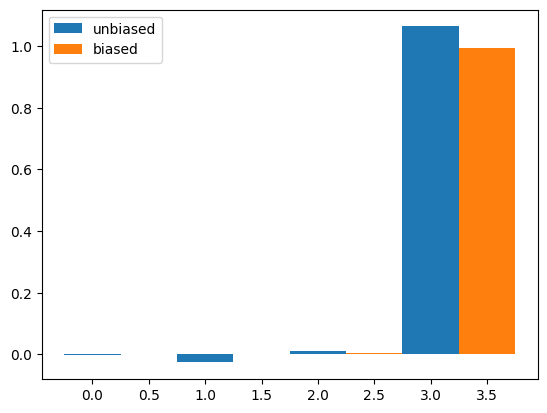

In [57]:
plt.bar(np.arange(4), values_unbiased, width=0.5, label='unbiased')
plt.bar(np.arange(4)+0.5, values_biased, width=0.5, label='biased')
plt.legend()

In [10]:
Q = np.random.randint(0,5,100)

In [14]:
a1 = np.percentile(Q,[25,50,75])
a2 = np.percentile(Q,[20,40,60,80])

In [15]:
np.digitize(Q, a1)

array([1, 3, 3, 3, 2, 1, 2, 3, 2, 1, 3, 0, 0, 3, 3, 1, 2, 2, 0, 0, 0, 0,
       0, 2, 2, 3, 3, 3, 2, 0, 3, 3, 0, 3, 2, 0, 0, 3, 2, 0, 3, 0, 0, 2,
       3, 2, 2, 3, 2, 1, 1, 0, 3, 2, 0, 0, 2, 0, 1, 3, 2, 3, 3, 0, 2, 0,
       0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 3, 2, 0, 0, 3, 2, 2, 3, 3, 3, 1, 3,
       2, 1, 3, 3, 2, 1, 3, 1, 2, 0, 1, 2], dtype=int64)

In [19]:
np.digitize(Q, a2)

array([1, 4, 4, 4, 3, 1, 2, 4, 2, 1, 4, 1, 1, 4, 4, 1, 3, 3, 1, 1, 1, 1,
       1, 2, 2, 4, 4, 4, 2, 1, 4, 4, 1, 4, 2, 1, 1, 4, 2, 1, 4, 1, 1, 3,
       4, 3, 3, 4, 2, 1, 1, 1, 4, 3, 1, 1, 3, 1, 1, 4, 2, 4, 4, 1, 2, 1,
       1, 3, 1, 2, 3, 2, 3, 2, 3, 3, 4, 3, 1, 1, 4, 3, 3, 4, 4, 4, 1, 4,
       2, 1, 4, 4, 2, 1, 4, 1, 2, 1, 1, 2], dtype=int64)

In [20]:
Q

array([1, 4, 4, 4, 3, 1, 2, 4, 2, 1, 4, 0, 0, 4, 4, 1, 3, 3, 0, 0, 0, 0,
       0, 2, 2, 4, 4, 4, 2, 0, 4, 4, 0, 4, 2, 0, 0, 4, 2, 0, 4, 0, 0, 3,
       4, 3, 3, 4, 2, 1, 1, 0, 4, 3, 0, 0, 3, 0, 1, 4, 2, 4, 4, 0, 2, 0,
       0, 3, 0, 2, 3, 2, 3, 2, 3, 3, 4, 3, 0, 0, 4, 3, 3, 4, 4, 4, 1, 4,
       2, 1, 4, 4, 2, 1, 4, 1, 2, 0, 1, 2])